# Diabetic Retinopathy Stage Detection

Five-grade ICDR classification (0 No DR, 1 Mild, 2 Moderate, 3 Severe, 4 Proliferative DR) with
transfer learning on EfficientNetV2-B0. Trained on **DDR**, tested on a held-out DDR split and on
**IDRiD** as an external dataset the model never sees.

**How to run:** set the options in **0.2 Config**, then *Run All*. To try another setting (for example
`TRAIN_SIZE = 4000`), edit 0.2, run 0.2, then run from **3.1** to the end. Every run is saved under
`/kaggle/working/runs/<RUN_TAG>/` and 6.7 compares all runs found.

**Kaggle settings:** GPU T4, Internet on, Persistence = *Files only*.

---
## 0. Setup

In [ ]:
# 0.1 Imports, GPU and mixed precision
import os, re, json, time, shutil, pathlib, subprocess, warnings
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (classification_report, confusion_matrix, cohen_kappa_score,
                             accuracy_score, f1_score, recall_score, roc_auc_score)

try:
    import imagehash
except ImportError:
    subprocess.run(['pip', '-q', 'install', 'imagehash'], check=True)
    import imagehash

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore', category=UserWarning)
cv2.setNumThreads(1)
pd.set_option('display.width', 160)

LABELS = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferative_DR']
WEIGHTS = 'imagenet'

gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow', tf.__version__, '| Keras', keras.__version__)
print('GPU:', [g.name for g in gpus] or 'none - training will be very slow')
if gpus:
    cc = tf.config.experimental.get_device_details(gpus[0]).get('compute_capability')
    if cc and cc >= (7, 0):
        keras.mixed_precision.set_global_policy('mixed_float16')
print('precision policy:', keras.mixed_precision.global_policy().name)

TensorFlow 2.20.0 | Keras 3.13.2
GPU: ['/physical_device:GPU:0', '/physical_device:GPU:1']
precision policy: mixed_float16


In [ ]:
# 0.2 Config
class Config:
    # data
    TRAIN_SIZE = 'full'                # 2000 | 4000 | 8000 | 'full'
    SPLIT      = (0.70, 0.15, 0.15)    # train / val / test share of DDR
    SEED       = 42
    IMG_SIZE   = 768
    BATCH_SIZE = 16
    NORM       = 'none'                # 'none' | 'clahe'

    # model
    HEAD       = 'dense'               # 'dense' = GAP-BN-Dropout-Dense(256)-Dropout-Dense(5)
                                       # 'simple' = GAP-Dropout-Dense(5)
    DROPOUT    = 0.3
    UNFREEZE   = 0.50

    # training
    LOSS          = 'focal'            # 'focal' | 'ce_weighted'
    FOCAL_GAMMA   = 2.0
    PHASE1_EPOCHS = 5
    PHASE1_LR     = 1e-3
    PHASE2_EPOCHS = 30
    PHASE2_LR     = 1e-4
    PHASE3_WEAK_CLASSES = False
    PHASE3_TARGETS      = (1, 3)
    PHASE3_EPOCHS       = 15
    PHASE3_LR           = 3e-5
    ES_PATIENCE   = 5
    RLR_PATIENCE  = 2
    RLR_FACTOR    = 0.3
    CLEAN_N       = 500

    # augmentation
    ROTATION   = 360
    ZOOM       = (0.90, 1.10)
    BRIGHTNESS = 0.20
    CONTRAST   = 0.10
    CHANNEL    = 0.05

    # preprocessing
    CACHE_SIZE = 768
    MASK_FRAC  = 0.95

    MERGE_EXTRA = False
    RUN_TAG = f'{TRAIN_SIZE}_{HEAD}_{NORM}_{LOSS}_{IMG_SIZE}' \
              + ('_merged' if MERGE_EXTRA else '') + ('_p3' if PHASE3_WEAK_CLASSES else '')

C = Config
print('run tag:', C.RUN_TAG)
print({k: v for k, v in vars(Config).items() if not k.startswith('_')})

run tag: full_dense_none_focal_768
{'TRAIN_SIZE': 'full', 'SPLIT': (0.7, 0.15, 0.15), 'SEED': 42, 'IMG_SIZE': 768, 'BATCH_SIZE': 16, 'NORM': 'none', 'HEAD': 'dense', 'DROPOUT': 0.3, 'UNFREEZE': 0.5, 'LOSS': 'focal', 'FOCAL_GAMMA': 2.0, 'PHASE1_EPOCHS': 5, 'PHASE1_LR': 0.001, 'PHASE2_EPOCHS': 30, 'PHASE2_LR': 0.0001, 'PHASE3_WEAK_CLASSES': False, 'PHASE3_TARGETS': (1, 3), 'PHASE3_EPOCHS': 15, 'PHASE3_LR': 3e-05, 'ES_PATIENCE': 5, 'RLR_PATIENCE': 2, 'RLR_FACTOR': 0.3, 'CLEAN_N': 500, 'ROTATION': 360, 'ZOOM': (0.9, 1.1), 'BRIGHTNESS': 0.2, 'CONTRAST': 0.1, 'CHANNEL': 0.05, 'CACHE_SIZE': 768, 'MASK_FRAC': 0.95, 'MERGE_EXTRA': False, 'RUN_TAG': 'full_dense_none_focal_768'}


In [ ]:
# 0.3 Paths and input files
INPUT = pathlib.Path('/kaggle/input')
WORK  = pathlib.Path('/kaggle/working')
RUNS  = WORK / 'runs'
RUNS.mkdir(parents=True, exist_ok=True)

def find_input(pattern):
    hits = sorted(INPUT.rglob(pattern))
    return hits[0] if hits else None

def need_input(pattern):
    p = find_input(pattern)
    assert p is not None, f'{pattern} not found under /kaggle/input - add the dataset to the notebook'
    return p

DDR_CSV   = need_input('DR_grading.csv')
IDRID_CSV = need_input('idrid_labels.csv')
OFF_TRAIN = need_input('*IDRiD_Disease_Grading_Training_Labels.csv')
OFF_TEST  = need_input('*IDRiD_Disease_Grading_Testing_Labels.csv')
DDR_IMG   = DDR_CSV.parent / 'DR_grading' / 'DR_grading'
IDRID_IMG = IDRID_CSV.parent / 'Imagenes' / 'Imagenes'
for p in (DDR_IMG, IDRID_IMG):
    assert p.is_dir(), f'image folder not found: {p}'

CACHE_SPEC = {'out_size': C.CACHE_SIZE, 'mask_frac': C.MASK_FRAC}
PROC = WORK / f'processed_{C.CACHE_SIZE}'
for m in INPUT.rglob('manifest.json'):
    try:
        spec = json.loads(m.read_text())
    except Exception:
        continue
    if {k: spec.get(k) for k in CACHE_SPEC} == CACHE_SPEC and (m.parent / 'ddr').is_dir():
        PROC = m.parent
        break

print('DDR   :', DDR_CSV.parent)
print('IDRiD :', IDRID_CSV.parent)
print('cache :', PROC, '(attached input)' if str(PROC).startswith(str(INPUT)) else '(built in 2.3 if missing)')

DDR   : /kaggle/input/datasets/mariaherrerot/ddrdataset
IDRiD : /kaggle/input/datasets/mariaherrerot/idrid-dataset
cache : /kaggle/working/processed_768 (built in 2.3 if missing)


---
## 1. Dataset
DDR (147 hospitals, 12,522 images) is used for training, validation and internal testing. IDRiD
(one clinic, 455 images) is kept entirely for external testing. Both use the ICDR 0-4 scale.

## Section 1: Dataset Analysis

- Load DDR labels: tag each image by its filename source, hyphen or timestamp.
- Load IDRiD labels: clean up columns, derive the train/test split from the filename.
- Correct IDRiD labels against the official source, replacing wrong grades.
- Show DDR and IDRiD class counts and percentages side by side.
- Show DDR's class imbalance ratio, largest class to smallest.
- Show one raw sample image per grade, for both DDR and IDRiD.

IDRiD labels corrected: 27 of 455
                   DDR  IDRiD  DDR %  IDRiD %
No_DR             6266    118   50.0     25.9
Mild               630     23    5.0      5.1
Moderate          4477    164   35.8     36.0
Severe             236     90    1.9     19.8
Proliferative_DR   913     60    7.3     13.2

DDR imbalance (largest / smallest class): 26.6 : 1


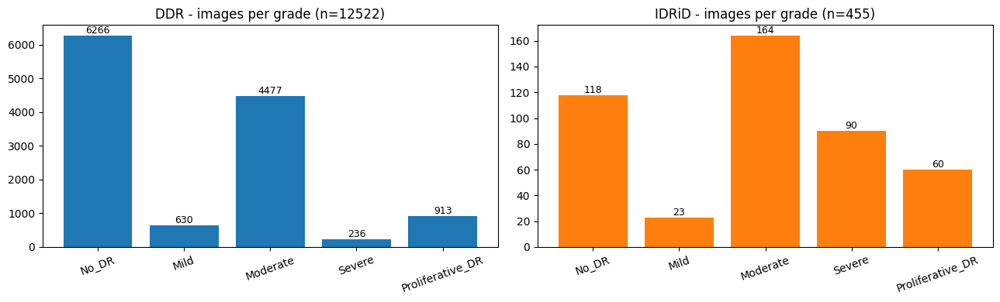

In [ ]:
# 1.1 Load labels, correct IDRiD, class distribution

ddr = pd.read_csv(DDR_CSV)[['id_code', 'diagnosis']]

ddr['source'] = np.where(ddr['id_code'].str.match(r'^\d{3}-\d{4}-\d{3}'), 'hyphen', 'timestamp')
on_disk = {p.name for p in DDR_IMG.iterdir()}
assert ddr['id_code'].isin(on_disk).all(), 'some labelled DDR images are missing'

idr = pd.read_csv(IDRID_CSV)
idr = idr.loc[:, ~idr.columns.str.startswith('Unnamed')].iloc[:, :2].set_axis(['id_code', 'rehost'], axis=1)
idr['split'] = np.where(idr['id_code'].str.endswith('test'), 'test', 'train')

official = pd.concat([pd.read_csv(p).iloc[:, :2].set_axis(['name', 'diagnosis'], axis=1).assign(split=s)
                      for s, p in (('train', OFF_TRAIN), ('test', OFF_TEST))], ignore_index=True)
official['name'] = official['name'].astype(str).str.strip()
idr = (idr.assign(name=idr['id_code'].str.replace('test', '', regex=False))
          .merge(official, on=['name', 'split'], how='left'))
assert idr['diagnosis'].notna().all(), 'IDRiD images without an official label'
idr['diagnosis'] = idr['diagnosis'].astype(int)
print(f"IDRiD labels corrected: {(idr['rehost'] != idr['diagnosis']).sum()} of {len(idr)}")
idr = idr[['id_code', 'diagnosis']]

counts = pd.DataFrame({'DDR': ddr['diagnosis'].value_counts().sort_index(),
                       'IDRiD': idr['diagnosis'].value_counts().sort_index()}).fillna(0).astype(int)
counts.index = LABELS
table = counts.assign(**{'DDR %': (counts['DDR'] / counts['DDR'].sum() * 100).round(1),
                         'IDRiD %': (counts['IDRiD'] / counts['IDRiD'].sum() * 100).round(1)})
print(table.to_string())
print(f"\nDDR imbalance (largest / smallest class): {counts['DDR'].max() / counts['DDR'].min():.1f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, colour in zip(axes, ['DDR', 'IDRiD'], ['tab:blue', 'tab:orange']):
    ax.bar(LABELS, counts[col], color=colour)
    for i, v in enumerate(counts[col]):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{col} - images per grade (n={counts[col].sum()})')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

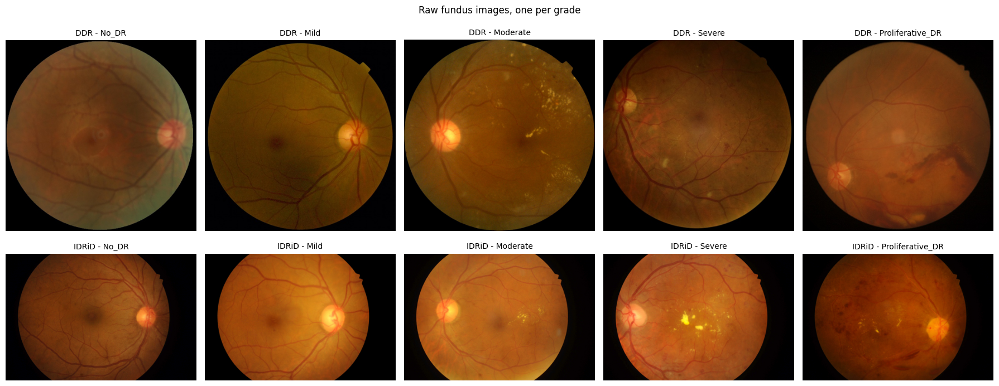

In [ ]:
# 1.2 Sample images per grade (raw, before preprocessing)
rng = np.random.default_rng(C.SEED)
fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
for g in range(5):
    for row, (name, frame, folder, ext) in enumerate([('DDR', ddr, DDR_IMG, ''), ('IDRiD', idr, IDRID_IMG, '.jpg')]):
        ids = frame.loc[frame['diagnosis'] == g, 'id_code'].to_numpy()
        with Image.open(folder / f'{rng.choice(ids)}{ext}') as im:
            im.thumbnail((400, 400))
            axes[row, g].imshow(im)
        axes[row, g].set_title(f'{name} - {LABELS[g]}', fontsize=10)
        axes[row, g].axis('off')
plt.suptitle('Raw fundus images, one per grade', y=1.0)
plt.tight_layout(); plt.show()

### 1.3 Key findings carried over from the full dataset analysis
- **Imbalance:** DDR is 50.0% No DR and 1.9% Severe (26.6 : 1). Accuracy alone is misleading, so
  QWK, macro F1 and per-class recall are reported.
- **Two capture sources:** filename style (hyphen / timestamp) separates two groups with very different
  grade mixes (hyphen holds 99.9% of PDR). Splits keep the same source mix per grade.
- **Near-duplicates:** 30 groups (65 images) of near-identical photos, found with a 256-bit perceptual
  hash. Each group is kept inside one split so no test image has a copy in training.
- **IDRiD labels:** the Kaggle rehost disagrees with the official labels on 27 images (5.9%);
  official labels are used.
- **Prevalence gap:** Severe is 1.9% of DDR but 19.8% of IDRiD, so IDRiD gives a meaningful
  Severe recall.
- **Ethics and limits:** de-identified public data, labels from graders who can disagree on Mild vs
  Moderate, populations limited to China (DDR) and India (IDRiD).

---
## Section 2: Preprocessing
Each image: find the round retina, apply a circular mask at 95% of its radius, crop to a square and
resize to 512 px. This runs **once** and is saved. Contrast enhancement (CLAHE) is optional
(`Config.NORM`) and is applied when images are loaded.

- Retina detection: locate the round bright region in the photo.
- 5% edge trim: shrink the detected radius by 5% to cut the camera notch.
- Centre on a black square canvas: paste the retina region onto a black square sized to fit it.
- Circular masking: black out everything outside the circle.
- Resize: scale the square to the configured size.
- Optional CLAHE: local contrast boost on brightness only, off by default.

In [ ]:
# 2.1 Preprocessing functions
def detect_fov(img, thresh=12, work=512):
    s = work / max(img.shape[:2])
    sm = cv2.resize(img, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    m = (sm.max(2) > thresh).astype(np.uint8)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    x, y, w, h = cv2.boundingRect(max(cnts, key=cv2.contourArea))
    return (x + w / 2) / s, (y + h / 2) / s, max(w, h) / 2 / s

def circle_mask(side, frac=1.0):
    yy, xx = np.ogrid[:side, :side]
    c = side / 2
    return (xx - c) ** 2 + (yy - c) ** 2 <= (c * frac) ** 2

def preprocess(path, out=C.CACHE_SIZE, mask_frac=C.MASK_FRAC):
    img = cv2.imread(str(path))
    if img is None:
        return None
    fov = detect_fov(img)
    if fov is None:
        return None
    cx, cy, r = fov
    r *= mask_frac
    side = int(round(2 * r))
    x0, y0 = int(round(cx - r)), int(round(cy - r))
    canvas = np.zeros((side, side, 3), np.uint8)
    sx0, sy0 = max(x0, 0), max(y0, 0)
    sx1, sy1 = min(x0 + side, img.shape[1]), min(y0 + side, img.shape[0])
    canvas[sy0 - y0:sy1 - y0, sx0 - x0:sx1 - x0] = img[sy0:sy1, sx0:sx1]
    canvas[~circle_mask(side)] = 0
    interp = cv2.INTER_AREA if side > out else cv2.INTER_CUBIC
    return cv2.resize(canvas, (out, out), interpolation=interp)

_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def apply_clahe(img):
    black = img.max(2) == 0
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    lab[:, :, 0] = _clahe.apply(lab[:, :, 0])
    out = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    out[black] = 0
    return out

print('preprocessing functions ready')

preprocessing functions ready


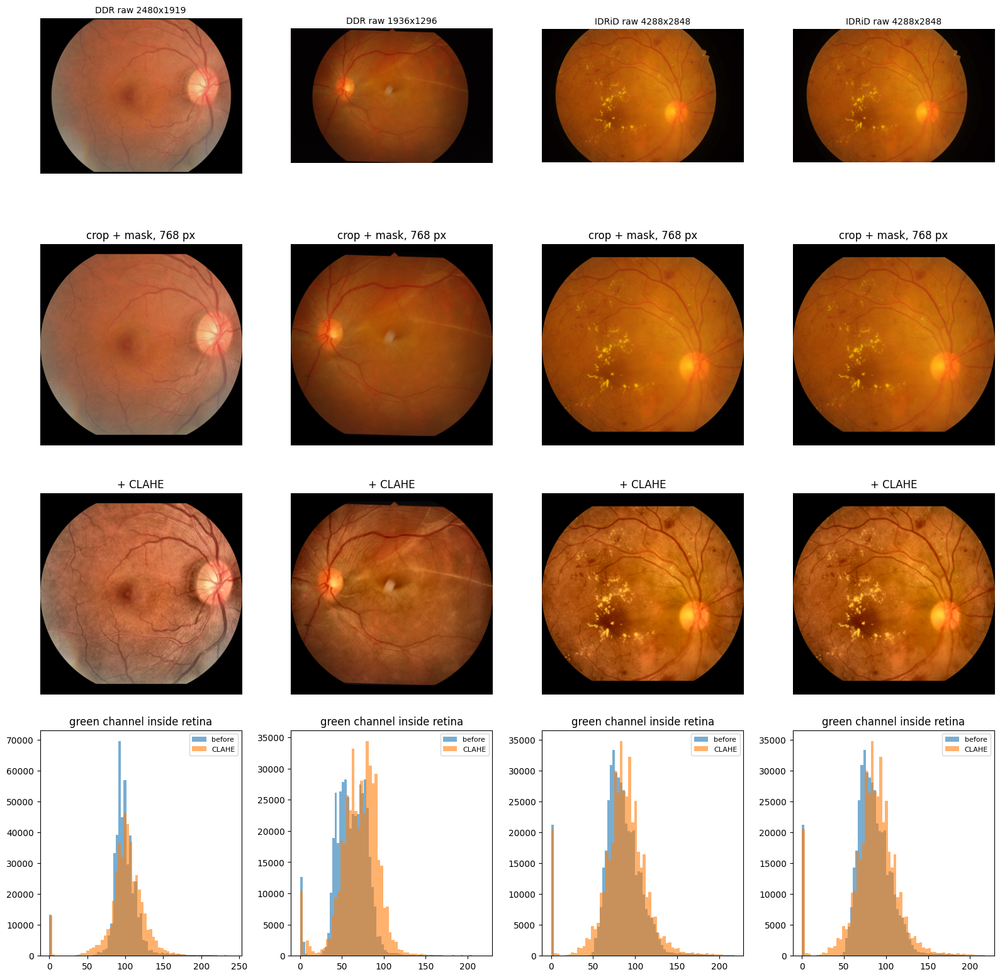

CLAHE widens the brightness range inside the retina, which makes small lesions stand out more.


In [ ]:
# 2.2 Before / after: raw -> cropped and masked -> CLAHE
examples = [('DDR', DDR_IMG / ddr['id_code'].iloc[0]),
            ('DDR', DDR_IMG / ddr.loc[ddr['diagnosis'] == 4, 'id_code'].iloc[0]),
            ('IDRiD', IDRID_IMG / f"{idr['id_code'].iloc[0]}.jpg"),
            ('IDRiD', IDRID_IMG / f"{idr.loc[idr['diagnosis'] == 3, 'id_code'].iloc[0]}.jpg")]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for col, (name, path) in enumerate(examples):
    with Image.open(path) as im:
        axes[0, col].imshow(im.resize((400, int(400 * im.size[1] / im.size[0]))))
        axes[0, col].set_title(f'{name} raw {im.size[0]}x{im.size[1]}', fontsize=10)
    out = preprocess(path)
    enh = apply_clahe(out)
    axes[1, col].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB)); axes[1, col].set_title(f'crop + mask, {C.CACHE_SIZE} px')
    axes[2, col].imshow(cv2.cvtColor(enh, cv2.COLOR_BGR2RGB)); axes[2, col].set_title('+ CLAHE')
    inside = circle_mask(out.shape[0], 0.98)
    axes[3, col].hist(out[:, :, 1][inside], bins=64, alpha=0.6, label='before')
    axes[3, col].hist(enh[:, :, 1][inside], bins=64, alpha=0.6, label='CLAHE')
    axes[3, col].set_title('green channel inside retina'); axes[3, col].legend(fontsize=8)
    for r in range(3):
        axes[r, col].axis('off')
    assert out.shape == (C.CACHE_SIZE, C.CACHE_SIZE, 3) and out[:8, :8].max() == 0
plt.tight_layout(); plt.show()
print('CLAHE widens the brightness range inside the retina, which makes small lesions stand out more.')

In [ ]:
# 2.3 Build the processed image cache (skipped when it already exists) to ensure that runtime doesnt have to deal with preprocessing for each image inside
def cache_job(args):
    src, dst = args
    if os.path.exists(dst):
        return 'skip'
    out = preprocess(src)
    if out is None:
        return 'fail'
    return 'ok' if cv2.imwrite(dst, out, [cv2.IMWRITE_JPEG_QUALITY, 95]) else 'fail'

manifest = PROC / 'manifest.json'
expected = {'ddr': len(ddr), 'idrid': len(idr)}
ready = manifest.exists() and all(len(list((PROC / k).glob('*.jpg'))) >= n for k, n in expected.items())

if not ready:
    assert not str(PROC).startswith(str(INPUT)), 'attached cache is incomplete - remove it or rebuild'
    for sub in expected:
        (PROC / sub).mkdir(parents=True, exist_ok=True)
    jobs = [(str(DDR_IMG / n), str(PROC / 'ddr' / n)) for n in ddr['id_code']]
    jobs += [(str(IDRID_IMG / f'{n}.jpg'), str(PROC / 'idrid' / f'{n}.jpg')) for n in idr['id_code']]
    t0, tally = time.time(), {'ok': 0, 'skip': 0, 'fail': 0}
    workers = max(2, os.cpu_count() or 2)
    print(f'preprocessing {len(jobs)} images on {workers} workers ...')
    with ProcessPoolExecutor(workers, mp_context=mp.get_context('fork')) as ex:
        for k, res in enumerate(ex.map(cache_job, jobs, chunksize=32), 1):
            tally[res] += 1
            if k % 2000 == 0:
                print(f'  {k}/{len(jobs)}  {time.time() - t0:.0f}s  {tally}')
    assert tally['fail'] == 0, f"{tally['fail']} images failed"
    manifest.write_text(json.dumps(CACHE_SPEC))
    print(f'done in {time.time() - t0:.0f}s')

sample = cv2.imread(str(PROC / 'ddr' / ddr['id_code'].iloc[0]))
print('cache:', PROC, '|', {k: len(list((PROC / k).glob('*.jpg'))) for k in expected})
print('image shape', sample.shape, '| dtype', sample.dtype, '| range', sample.min(), '-', sample.max())

preprocessing 12977 images on 4 workers ...
  2000/12977  6s  {'ok': 343, 'skip': 1657, 'fail': 0}
  4000/12977  50s  {'ok': 2343, 'skip': 1657, 'fail': 0}
  6000/12977  95s  {'ok': 4343, 'skip': 1657, 'fail': 0}


Corrupt JPEG data: 35 extraneous bytes before marker 0xd9


  8000/12977  126s  {'ok': 6343, 'skip': 1657, 'fail': 0}
  10000/12977  159s  {'ok': 8343, 'skip': 1657, 'fail': 0}


Corrupt JPEG data: 38 extraneous bytes before marker 0xd9
Corrupt JPEG data: 34 extraneous bytes before marker 0xd9


  12000/12977  190s  {'ok': 10343, 'skip': 1657, 'fail': 0}
done in 264s
cache: /kaggle/working/processed_768 | {'ddr': 12522, 'idrid': 455}
image shape (768, 768, 3) | dtype uint8 | range 0 - 248


In [ ]:
# 2.4 EyePACS Mild + Severe as extra training data (never used for val, test or IDRiD)

EYEPACS_CSV = find_input('trainLabels.csv')
EXTRA_CLASSES = [1, 3]

if not getattr(C, 'MERGE_EXTRA', False):
    extra = None
    print('MERGE_EXTRA is False - skipping EyePACS (DDR only)')
elif EYEPACS_CSV is None:
    extra = None
    print('EyePACS not attached - training on DDR only')
else:
    ep = pd.read_csv(EYEPACS_CSV)
    ep.columns = [c.strip().lower() for c in ep.columns]
    ep = ep.rename(columns={'image': 'id_code', 'level': 'diagnosis'})[['id_code', 'diagnosis']]
    print('EyePACS full set:', len(ep))
    print(ep['diagnosis'].value_counts().sort_index().set_axis(LABELS).to_string())

    sample = next((p for p in EYEPACS_CSV.parent.rglob('*')
                   if p.suffix.lower() in {'.jpeg', '.jpg', '.png'}), None)
    assert sample is not None, 'no EyePACS image files found'
    EP_IMG, ext = sample.parent, sample.suffix
    print('images:', EP_IMG, '| extension', ext)

    extra = ep[ep['diagnosis'].isin(EXTRA_CLASSES)].copy()
    print(f'\ntaking {len(extra)} images ({", ".join(LABELS[c] for c in EXTRA_CLASSES)}) out of {len(ep)}')

    (PROC / 'eyepacs').mkdir(parents=True, exist_ok=True)
    jobs = [(str(EP_IMG / f'{n}{ext}'), str(PROC / 'eyepacs' / f'{n}.jpg')) for n in extra['id_code']]
    jobs = [(s, d) for s, d in jobs if os.path.exists(s)]
    print(f'{len(jobs)} files found on disk')
    t0, tally = time.time(), {'ok': 0, 'skip': 0, 'fail': 0}
    with ProcessPoolExecutor(max(2, os.cpu_count() or 2), mp_context=mp.get_context('fork')) as ex:
        for k, res in enumerate(ex.map(cache_job, jobs, chunksize=32), 1):
            tally[res] += 1
            if k % 1000 == 0:
                print(f'  {k}/{len(jobs)}  {time.time() - t0:.0f}s  {tally}')
    print(f'preprocessed in {time.time() - t0:.0f}s {tally}')

    extra = extra[[(PROC / 'eyepacs' / f'{n}.jpg').exists() for n in extra['id_code']]]
    print('\nusable EyePACS images:', len(extra))
    print(extra['diagnosis'].value_counts().sort_index().to_string())
    print('\nafter merge, training counts would be:')
    print(pd.concat([train_df['diagnosis'], extra['diagnosis']]).value_counts().sort_index()
          .set_axis(LABELS).to_string())

    # preview: EyePACS vs DDR, same grade, raw and processed
    fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
    for col, c in enumerate(EXTRA_CLASSES):
        n = extra[extra['diagnosis'] == c]['id_code'].iloc[0]
        with Image.open(EP_IMG / f'{n}{ext}') as im:
            axes[0, col * 2].imshow(im); axes[0, col * 2].set_title(f'EyePACS raw - {LABELS[c]}', fontsize=10)
        axes[1, col * 2].imshow(cv2.cvtColor(cv2.imread(str(PROC / 'eyepacs' / f'{n}.jpg')), cv2.COLOR_BGR2RGB))
        axes[1, col * 2].set_title('EyePACS processed', fontsize=10)

        d = train_df[train_df['diagnosis'] == c]['id_code'].iloc[0]
        with Image.open(DDR_IMG / d) as im:
            im.thumbnail((500, 500)); axes[0, col * 2 + 1].imshow(im)
            axes[0, col * 2 + 1].set_title(f'DDR raw - {LABELS[c]}', fontsize=10)
        axes[1, col * 2 + 1].imshow(cv2.cvtColor(cv2.imread(str(PROC / 'ddr' / d)), cv2.COLOR_BGR2RGB))
        axes[1, col * 2 + 1].set_title('DDR processed', fontsize=10)
    for ax in axes.ravel():
        ax.axis('off')
    plt.suptitle('EyePACS vs DDR, same grade, raw and after preprocessing', y=1.0)
    plt.tight_layout(); plt.show()

MERGE_EXTRA is False - skipping EyePACS (DDR only)


---
## Section 3: Data Splitting and Augmentation

**Purpose:** split DDR into train, validation and test without leaking duplicates across splits, then define how training images are randomly varied on the fly during training.

**Splitting (3.1)**
- Detect near-duplicate DDR images, keeping whole duplicate groups inside a single split.
- Split DDR into 70% train, 15% validation, 15% test, stratified by grade and source.
- Optionally subsample training, always keeping every rare-class image intact.
- Optionally merge in extra EyePACS images for the rare classes, training set only.

**Class weights (3.2)**
- Compute per-class weights, available if the loss function is set to use them.

**Augmentation, applied live during training (3.3)**

Every training image is loaded fresh each epoch and randomly varied, in this order:
1. Rotate and zoom, in one combined step.
2. Flip horizontally, 50% chance.
3. Flip vertically, 50% chance.
4. Adjust contrast, pulling the image toward or away from its own mean colour.
5. Adjust brightness, scaling the whole image lighter or darker.
6. Adjust colour balance, scaling blue, green and red independently.
7. Re-mask the background to pure black, sized correctly even after zoom.

Validation, test and IDRiD images skip this entirely, they are loaded once, unchanged, and always produce identical results.

**Key outputs**

| Split | No_DR | Mild | Moderate | Severe | PDR | Total |
|---|---:|---:|---:|---:|---:|---:|
| Train (used) | 4,482 | 447 | 3,196 | 170 | 654 | 8,949 |
| Validation | 887 | 91 | 644 | 33 | 130 | 1,785 |
| Test | 897 | 92 | 637 | 33 | 129 | 1,788 |
| IDRiD | 118 | 23 | 164 | 90 | 60 | 455 |

Training imbalance: 26.4:1 (largest class to smallest).

In [ ]:
# 3.1 Duplicate groups, group-aware split, TRAIN_SIZE subset, optional EyePACS merge

DUP_CSV = find_input('ddr_dup_groups.csv') or WORK / 'ddr_dup_groups.csv'
if not DUP_CSV.exists():
    def phash_bits(path):
        with Image.open(path) as im:
            return np.array(imagehash.phash(im.convert('RGB').resize((256, 256)), hash_size=16).hash).ravel()
    t0 = time.time()
    with ProcessPoolExecutor(max(2, os.cpu_count() or 2), mp_context=mp.get_context('fork')) as ex:
        bits = np.stack(list(ex.map(phash_bits, [str(DDR_IMG / n) for n in ddr['id_code']], chunksize=64)))
    b, ones, rows, cols = bits.astype(np.float32), bits.sum(1).astype(np.float32), [], []
    for i0 in range(0, len(b), 2000):
        d = ones[i0:i0 + 2000, None] + ones[None, :] - 2 * (b[i0:i0 + 2000] @ b.T)
        i, j = np.where(d <= 8)
        keep = j > i + i0
        rows += list(i[keep] + i0); cols += list(j[keep])
    adj = sp.coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(len(b), len(b)))
    _, group = connected_components(adj, directed=False)
    pd.DataFrame({'id_code': ddr['id_code'], 'group': group}).to_csv(WORK / 'ddr_dup_groups.csv', index=False)
    DUP_CSV = WORK / 'ddr_dup_groups.csv'
    print(f'duplicate groups built in {time.time() - t0:.0f}s')

base = ddr.merge(pd.read_csv(DUP_CSV)[['id_code', 'group']], on='id_code', how='left')
assert base['group'].notna().all()
sizes = base['group'].value_counts()
print(f"near-duplicate groups: {(sizes > 1).sum()} ({sizes[sizes > 1].sum()} images)")

n_outer = max(2, round(1 / C.SPLIT[2]))
n_inner = max(2, round((1 - 1 / n_outer) / C.SPLIT[1]))
SPLIT_SPEC = {'seed': C.SEED, 'outer_folds': n_outer, 'inner_folds': n_inner}
split_csv = WORK / f'ddr_splits_{n_outer}x{n_inner}.csv'
base['stratum'] = base['diagnosis'].astype(str) + '-' + base['source']

def leak_free(frame):
    return (frame.groupby('group')['split'].nunique() == 1).all()

splits = None
old = find_input('ddr_splits.csv')
for candidate in [split_csv, old]:
    if candidate is None or not candidate.exists():
        continue
    man = candidate.with_name('ddr_splits_manifest.json')
    if candidate == old and not (man.exists() and
            {k: json.loads(man.read_text()).get(k) for k in SPLIT_SPEC} == SPLIT_SPEC):
        continue
    s = pd.read_csv(candidate)[['id_code', 'split']]
    if set(s['id_code']) == set(base['id_code']):
        s = base.merge(s, on='id_code')
        if leak_free(s):
            splits, source = s, candidate
            break

if splits is None:
    def hold_out(frame, k):
        keep, hold = next(StratifiedGroupKFold(k, shuffle=True, random_state=C.SEED)
                          .split(frame, frame['stratum'], frame['group']))
        return frame.iloc[keep], frame.iloc[hold]
    trainval, test_part = hold_out(base, n_outer)
    train_part, val_part = hold_out(trainval, n_inner)
    splits = base.assign(split=np.select([base['id_code'].isin(train_part['id_code']),
                                          base['id_code'].isin(val_part['id_code'])], ['train', 'val'], 'test'))
    source = 'built'
splits[['id_code', 'diagnosis', 'source', 'group', 'split']].to_csv(split_csv, index=False)
assert leak_free(splits), 'a duplicate group crosses splits'
print('split:', source)

pool = splits[splits['split'] == 'train']
if C.TRAIN_SIZE == 'full' or C.TRAIN_SIZE >= len(pool):
    train_df = pool
else:
    rare = pool[pool['diagnosis'].isin([1, 3, 4])]
    left = C.TRAIN_SIZE - len(rare)
    if left <= 0:
        train_df = pool.groupby('diagnosis').sample(frac=C.TRAIN_SIZE / len(pool), random_state=C.SEED)
    else:
        big = {c: pool[pool['diagnosis'] == c] for c in (0, 2)}
        take = {0: 0, 2: 0}
        while left > 0:
            open_c = [c for c in take if take[c] < len(big[c])]
            if not open_c:
                break
            share = max(1, left // len(open_c))
            for c in open_c:
                add = min(share, len(big[c]) - take[c], left)
                take[c] += add; left -= add
        train_df = pd.concat([rare] + [big[c].sample(take[c], random_state=C.SEED) for c in take])

train_df = train_df[['id_code', 'diagnosis']].assign(folder='ddr')
ddr_only_counts = train_df['diagnosis'].value_counts().sort_index()
if getattr(C, 'MERGE_EXTRA', False) and 'extra' in dir() and extra is not None:
    train_df = pd.concat([train_df, extra[['id_code', 'diagnosis']].assign(folder='eyepacs')], ignore_index=True)
    print(f"\nmerged {len(extra)} EyePACS images into training "
          f"({', '.join(LABELS[c] for c in sorted(extra['diagnosis'].unique()))})")
    print(pd.DataFrame({'DDR only': ddr_only_counts,
                        '+ EyePACS': train_df['diagnosis'].value_counts().sort_index()})
          .fillna(0).astype(int).set_axis(LABELS).to_string())
train_df = train_df.sample(frac=1, random_state=C.SEED)

val_df  = splits[splits['split'] == 'val']
test_df = splits[splits['split'] == 'test']

tab = pd.DataFrame({'train (used)': train_df['diagnosis'].value_counts(), 'train pool (DDR)': pool['diagnosis'].value_counts(),
                    'val': val_df['diagnosis'].value_counts(), 'test': test_df['diagnosis'].value_counts(),
                    'IDRiD': idr['diagnosis'].value_counts()}).sort_index().fillna(0).astype(int)
tab.index = LABELS
tab.loc['total'] = tab.sum()
print('\n' + tab.to_string())
tc = train_df['diagnosis'].value_counts()
print(f"\ntraining imbalance: {tc.max()} / {tc.min()} = {tc.max() / tc.min():.1f} : 1")
print('training sources:', train_df['folder'].value_counts().to_dict())
print('split share (%):', {k: round(100 * len(v) / len(splits), 1) for k, v in
                           [('train pool', pool), ('val', val_df), ('test', test_df)]})
assert all(tab.loc[LABELS, c].min() > 0 for c in ['train (used)', 'val', 'test']), 'a grade is missing from a split'

RUN_DIR = RUNS / C.RUN_TAG
RUN_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_ID = split_csv.stem
print('\nrun folder:', RUN_DIR)

near-duplicate groups: 126 (260 images)
split: /kaggle/working/ddr_splits_7x6.csv

                  train (used)  train pool (DDR)   val  test  IDRiD
No_DR                     4482              4482   887   897    118
Mild                       447               447    91    92     23
Moderate                  3196              3196   644   637    164
Severe                     170               170    33    33     90
Proliferative_DR           654               654   130   129     60
total                     8949              8949  1785  1788    455

training imbalance: 4482 / 170 = 26.4 : 1
training sources: {'ddr': 8949}
split share (%): {'train pool': 71.5, 'val': 14.3, 'test': 14.3}

run folder: /kaggle/working/runs/full_dense_none_focal_768


In [ ]:
# 3.2 Class weights (only used when LOSS = 'ce_weighted')
# "effective number of samples" (Cui et al., 2019): rarer classes get larger weights, less extreme than 1/count
beta = 0.999
n_c = train_df['diagnosis'].value_counts().sort_index().to_numpy()
w = (1 - beta) / (1 - beta ** n_c)
w = w / w.sum() * len(n_c)
CLASS_WEIGHTS = {i: float(v) for i, v in enumerate(w)}
share = w * n_c / (w * n_c).sum() * 100
print(pd.DataFrame({'images': n_c, 'weight': w.round(2), 'loss share %': share.round(1)}, index=LABELS).to_string())
print('\nused in training:', C.LOSS == 'ce_weighted')

                  images  weight  loss share %
No_DR               4482    0.38          39.2
Mild                 447    1.04          10.7
Moderate            3196    0.39          28.8
Severe               170    2.40           9.4
Proliferative_DR     654    0.78          11.8

used in training: False


In [ ]:
# 3.3 tf.data pipeline: load -> augment (train only) -> CLAHE (optional) -> batch
cv2.setNumThreads(1)
AUTOTUNE = tf.data.AUTOTUNE

def augment(img, rng):
    side = img.shape[0]
    zoom = rng.uniform(*C.ZOOM)
    M = cv2.getRotationMatrix2D((side / 2, side / 2), rng.uniform(0, C.ROTATION), zoom)
    x = cv2.warpAffine(img, M, (side, side), flags=cv2.INTER_LINEAR, borderValue=0)
    if rng.random() < 0.5:
        x = x[:, ::-1]
    if rng.random() < 0.5:
        x = x[::-1]
    x = np.ascontiguousarray(x)
    inside = circle_mask(side, min(zoom, 1.0))
    mean = np.array(cv2.mean(x, mask=inside.astype(np.uint8))[:3], np.float32)
    x = x.astype(np.float32)
    x = (x - mean) * (1 + rng.uniform(-C.CONTRAST, C.CONTRAST)) + mean
    x = x * (1 + rng.uniform(-C.BRIGHTNESS, C.BRIGHTNESS)) * (1 + rng.uniform(-C.CHANNEL, C.CHANNEL, 3))
    x = np.clip(x, 0, 255).astype(np.uint8)
    x[~inside] = 0
    return x

def load_image(path, training=False, norm=None):
    img = cv2.imread(path.decode() if isinstance(path, bytes) else str(path))
    if img.shape[0] != C.IMG_SIZE:
        img = cv2.resize(img, (C.IMG_SIZE, C.IMG_SIZE), interpolation=cv2.INTER_AREA)
    if training:
        img = augment(img, np.random.default_rng())
    if (norm or C.NORM) == 'clahe':
        img = apply_clahe(img)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)

def image_path(row_id, folder, default_dir):
    if folder == 'eyepacs':
        return str(PROC / 'eyepacs' / f'{row_id}.jpg')
    return str(default_dir / f'{row_id}')

def make_ds(frame, folder_dir, ext='', training=False):
    if 'folder' in frame.columns:
        srcs = frame['folder'].fillna('ddr')
    else:
        srcs = pd.Series(['ddr'] * len(frame), index=frame.index)
    paths = [image_path(f'{n}{ext}', s, folder_dir) for n, s in zip(frame['id_code'], srcs)]
    ds = tf.data.Dataset.from_tensor_slices((paths, frame['diagnosis'].to_numpy('int32')))
    if training:
        ds = ds.shuffle(len(paths), seed=C.SEED, reshuffle_each_iteration=True)
    def _load(p, y):
        x = tf.numpy_function(lambda q: load_image(q, training), [p], tf.float32)
        return tf.ensure_shape(x, (C.IMG_SIZE, C.IMG_SIZE, 3)), y
    return ds.map(_load, num_parallel_calls=AUTOTUNE).batch(C.BATCH_SIZE).prefetch(AUTOTUNE)

clean_df = train_df.groupby('diagnosis').sample(frac=min(1.0, C.CLEAN_N / len(train_df)), random_state=C.SEED)

train_ds = make_ds(train_df, PROC / 'ddr', training=True)
val_ds   = make_ds(val_df,   PROC / 'ddr')
test_ds  = make_ds(test_df,  PROC / 'ddr')
idrid_ds = make_ds(idr,      PROC / 'idrid', ext='.jpg')
clean_ds = make_ds(clean_df, PROC / 'ddr')
y_val, y_test, y_idrid, y_clean = (f['diagnosis'].to_numpy() for f in (val_df, test_df, idr, clean_df))

xb, yb = next(iter(train_ds))
print('batch', xb.shape, xb.dtype, '| pixel range %.0f-%.0f' % (xb.numpy().min(), xb.numpy().max()),
      '| labels in batch', sorted(set(yb.numpy().tolist())))
a, b2 = next(iter(val_ds))[0].numpy(), next(iter(val_ds))[0].numpy()
assert np.array_equal(a, b2), 'validation images must be identical on every pass'
if 'folder' in train_df.columns:
    print('training sources:', train_df['folder'].fillna('ddr').value_counts().to_dict())
print('images - train %d | val %d | test %d | IDRiD %d | clean-train %d'
      % (len(train_df), len(val_df), len(test_df), len(idr), len(clean_df)))

batch (16, 768, 768, 3) <dtype: 'float32'> | pixel range 0-255 | labels in batch [0, 2, 4]
training sources: {'ddr': 8949}
images - train 8949 | val 1785 | test 1788 | IDRiD 455 | clean-train 500


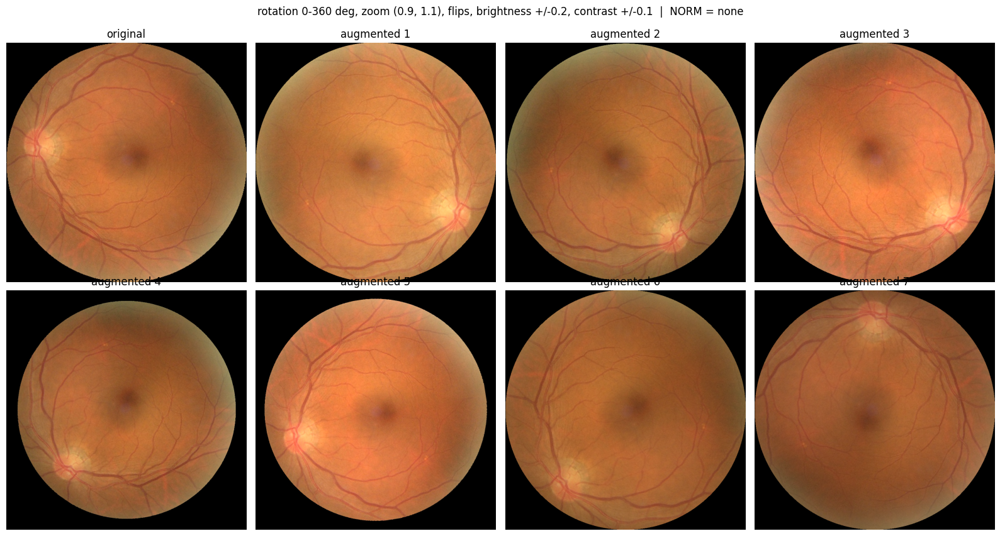

In [ ]:
# 3.4 Augmentation preview: one training image, eight random versions
probe = cv2.imread(str(PROC / 'ddr' / train_df['id_code'].iloc[1]))
rng = np.random.default_rng(C.SEED)
views = [('original', probe)] + [(f'augmented {k}', augment(probe, rng)) for k in range(1, 8)]
if C.NORM == 'clahe':
    views = [(t, apply_clahe(v)) for t, v in views]
fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for ax, (title, img) in zip(axes.ravel(), views):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(title); ax.axis('off')
plt.suptitle(f'rotation 0-{C.ROTATION} deg, zoom {C.ZOOM}, flips, brightness +/-{C.BRIGHTNESS}, '
             f'contrast +/-{C.CONTRAST}  |  NORM = {C.NORM}', y=1.0)
plt.tight_layout(); plt.savefig(RUN_DIR / 'augmentation.png', dpi=120, bbox_inches='tight'); plt.show()

---
## Section 4: CNN architecture and transfer learning
EfficientNetV2-B0 pre-trained on ImageNet. **Phase 1** trains only the new head with the backbone
frozen. **Phase 2** unfreezes the top part of the backbone and fine-tunes with a 10x lower learning rate.

In [ ]:
# 4.1 Build the model
keras.backend.clear_session()
keras.utils.set_random_seed(C.SEED)

def build_model(head=C.HEAD):
    inp = keras.Input((C.IMG_SIZE, C.IMG_SIZE, 3), name='rgb_0_255')
    base = keras.applications.EfficientNetV2B0(include_top=False, weights=WEIGHTS,
                                               input_shape=(C.IMG_SIZE, C.IMG_SIZE, 3),
                                               include_preprocessing=True)
    base.trainable = False
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    if head == 'dense':
        x = layers.BatchNormalization(name='head_bn')(x)
        x = layers.Dropout(C.DROPOUT, name='drop_1')(x)
        x = layers.Dense(256, activation='relu', name='dense_256')(x)
        x = layers.Dropout(C.DROPOUT, name='drop_2')(x)
    else:
        x = layers.Dropout(C.DROPOUT, name='drop_1')(x)
    out = layers.Dense(5, activation='softmax', dtype='float32', name='grade')(x)
    return keras.Model(inp, out, name=f'effnetv2b0_{head}'), base

model, base = build_model()
model.summary()
n_train = sum(int(np.prod(v.shape)) for v in model.trainable_weights)
print(f'backbone layers: {len(base.layers)} | trainable now (head only): {n_train:,} of {model.count_params():,}')

probe_out = model.predict(np.random.uniform(0, 255, (2, C.IMG_SIZE, C.IMG_SIZE, 3)).astype('float32'), verbose=0)
assert probe_out.shape == (2, 5) and np.allclose(probe_out.sum(1), 1, atol=1e-3)

Model: "effnetv2b0_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_0_255 (InputLayer)          │ (None, 768, 768, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 24, 24, 1280)   │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_bn (BatchNormalization)    │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ grade (Dense)                   │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,253,653 (23.86 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

backbone layers: 270 | trainable now (head only): 331,781 of 6,253,653


2026-09-18 18:34:25.459881: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 18:34:25.597430: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 18:34:26.390487: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 18:34:26.534076: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 18:34:27.344797: E external/local_xla/xla/stream_

---
## Section 5: Training Strategy

**Purpose:** define how the model is actually trained, run both training phases, and check the result isn't overfitting.

**Loss function and monitoring**
- Focal loss, gamma 2.0, so hard examples count more than easy ones the model already gets right.
- Track accuracy, loss, QWK and macro F1 on both a clean (unaugmented, 500-image) training subset and validation, every epoch, so the two are directly comparable.
- Track Mild and Severe recall and precision specifically, the two weakest classes.

**Callbacks**
- Checkpoint the best epoch by validation loss, and separately by validation QWK.
- Early stopping if validation loss doesn't improve for 5 epochs.
- Cut the learning rate by 0.3 if validation loss doesn't improve for 2 epochs, floored at 1e-7.

**Training runs**
- Phase 1: train only the head, backbone frozen, 5 epochs, learning rate 1e-3.
- Phase 2: unfreeze the top 50% of the backbone, fine-tune at learning rate 1e-4, up to 30 epochs, early stopping and LR reduction active.

**Overfitting check**
- Plot accuracy and loss for augmented training, clean training and validation together, across both phases.
- Compare clean-train accuracy against validation accuracy at the best epoch, to separate real overfitting from the expected gap caused by augmentation and dropout.

In [ ]:
# 5.1 Loss function and callbacks
def sparse_focal(gamma=C.FOCAL_GAMMA):
    # focal loss: cross-entropy multiplied by (1 - p_true)^gamma
    def loss(y_true, y_pred):
        y = keras.ops.cast(keras.ops.reshape(y_true, (-1,)), 'int32')
        p = keras.ops.clip(keras.ops.cast(y_pred, 'float32'), 1e-7, 1.0)
        pt = keras.ops.sum(keras.ops.one_hot(y, 5) * p, axis=-1)
        return keras.ops.mean(-keras.ops.power(1.0 - pt, gamma) * keras.ops.log(pt))
    loss.__name__ = 'focal'
    return loss

LOSS_FN = sparse_focal() if C.LOSS == 'focal' else keras.losses.SparseCategoricalCrossentropy()
FIT_WEIGHTS = CLASS_WEIGHTS if C.LOSS == 'ce_weighted' else None

class CleanTrainMetrics(keras.callbacks.Callback):
    def __init__(self, ds, y):
        super().__init__(); self.ds, self.y = ds, y
    def on_epoch_end(self, epoch, logs=None):
        p = self.model.predict(self.ds, verbose=0)
        logs['clean_accuracy'] = float((p.argmax(1) == self.y).mean())
        logs['clean_loss'] = float(keras.ops.convert_to_numpy(LOSS_FN(self.y, p)))

class ValQWK(keras.callbacks.Callback):
    def __init__(self, ds, y):
        super().__init__(); self.ds, self.y = ds, y
    def on_epoch_end(self, epoch, logs=None):
        yh = self.model.predict(self.ds, verbose=0).argmax(1)
        logs['val_qwk'] = float(cohen_kappa_score(self.y, yh, weights='quadratic'))
        logs['val_mild_recall'] = float(recall_score(self.y, yh, labels=[1], average='macro', zero_division=0))
        logs['val_mild_prec'] = float(precision_score(self.y, yh, labels=[1], average='macro', zero_division=0))
        logs['val_severe_recall'] = float(recall_score(self.y, yh, labels=[3], average='macro', zero_division=0))

def callbacks_for(phase):
    cbs = [CleanTrainMetrics(clean_ds, y_clean), ValQWK(val_ds, y_val)]
    if phase == 2:
        cbs += [keras.callbacks.ModelCheckpoint(str(RUN_DIR / 'best.weights.h5'), monitor='val_loss',
                                                save_best_only=True, save_weights_only=True, verbose=1),
                keras.callbacks.ModelCheckpoint(str(RUN_DIR / 'best_qwk.weights.h5'), monitor='val_qwk',
                                                mode='max', save_best_only=True, save_weights_only=True, verbose=1),
                keras.callbacks.EarlyStopping(monitor='val_loss', patience=C.ES_PATIENCE,
                                              restore_best_weights=True, verbose=1),
                keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=C.RLR_FACTOR,
                                                  patience=C.RLR_PATIENCE, min_lr=1e-7, verbose=1)]
    cbs.append(keras.callbacks.CSVLogger(str(RUN_DIR / f'history_phase{phase}.csv')))
    return cbs

print('loss:', C.LOSS, '| class weights in fit:', FIT_WEIGHTS is not None)
print('phase 2 callbacks:', [type(c).__name__ for c in callbacks_for(2)])

loss: focal | class weights in fit: False
phase 2 callbacks: ['CleanTrainMetrics', 'ValQWK', 'ModelCheckpoint', 'ModelCheckpoint', 'EarlyStopping', 'ReduceLROnPlateau', 'CSVLogger']


In [ ]:
# 5.2 Phase 1 - frozen backbone, train the head
model.compile(optimizer=keras.optimizers.Adam(C.PHASE1_LR), loss=LOSS_FN, metrics=['accuracy'])
t0 = time.time()
h1 = model.fit(train_ds, validation_data=val_ds, epochs=C.PHASE1_EPOCHS,
               class_weight=FIT_WEIGHTS, callbacks=callbacks_for(1), verbose=2)
print(f'phase 1: {time.time() - t0:.0f}s')

Epoch 1/5


2026-09-18 18:34:59.320792: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 18:34:59.496839: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 18:35:00.696365: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 18:35:00.898017: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 18:35:02.233899: E external/local_xla/xla/stream_

560/560 - 338s - 604ms/step - accuracy: 0.6033 - loss: 0.7714 - val_accuracy: 0.7003 - val_loss: 0.3787 - clean_accuracy: 0.6980 - clean_loss: 0.3530 - val_qwk: 0.6428 - val_mild_recall: 0.0000e+00 - val_mild_prec: 0.0000e+00 - val_severe_recall: 0.0606
Epoch 2/5
560/560 - 444s - 793ms/step - accuracy: 0.6603 - loss: 0.4269 - val_accuracy: 0.6980 - val_loss: 0.3641 - clean_accuracy: 0.7360 - clean_loss: 0.3228 - val_qwk: 0.6454 - val_mild_recall: 0.0330 - val_mild_prec: 0.1667 - val_severe_recall: 0.0000e+00
Epoch 3/5
560/560 - 437s - 780ms/step - accuracy: 0.6735 - loss: 0.3897 - val_accuracy: 0.7199 - val_loss: 0.3334 - clean_accuracy: 0.7160 - clean_loss: 0.2973 - val_qwk: 0.6906 - val_mild_recall: 0.0110 - val_mild_prec: 0.0769 - val_severe_recall: 0.0606
Epoch 4/5
560/560 - 265s - 473ms/step - accuracy: 0.6882 - loss: 0.3661 - val_accuracy: 0.7176 - val_loss: 0.3325 - clean_accuracy: 0.7180 - clean_loss: 0.3097 - val_qwk: 0.6679 - val_mild_recall: 0.0110 - val_mild_prec: 0.3333 - 

**Result. Head-only warm-up (5 epochs, backbone frozen).**

Validation QWK rose from 0.643 to 0.723, accuracy from 0.700 to 0.732. Clean accuracy tracked close to
validation throughout, so the augmented training numbers are trustworthy.

**Mild recall stayed near zero the whole phase** (0.000-0.033), consistent with the original notebook's
own head-only pilot, where Mild was the hardest class to learn even before fine-tuning began.

In [ ]:
# 5.3 Phase 2 - unfreeze the top of the backbone and fine-tune
base.trainable = True
cut = int(len(base.layers) * (1 - C.UNFREEZE))
for layer in base.layers[:cut]:
    layer.trainable = False
n_train = sum(int(np.prod(v.shape)) for v in model.trainable_weights)
print(f'unfrozen backbone layers: {len(base.layers) - cut} of {len(base.layers)} | trainable params: {n_train:,}')

model.compile(optimizer=keras.optimizers.Adam(C.PHASE2_LR), loss=LOSS_FN, metrics=['accuracy'])
t0 = time.time()
h2 = model.fit(train_ds, validation_data=val_ds, initial_epoch=C.PHASE1_EPOCHS,
               epochs=C.PHASE1_EPOCHS + C.PHASE2_EPOCHS, class_weight=FIT_WEIGHTS,
               callbacks=callbacks_for(2), verbose=2)
train_minutes = (time.time() - t0) / 60
model.load_weights(RUN_DIR / 'best.weights.h5')

hist = pd.concat([pd.DataFrame(h1.history), pd.DataFrame(h2.history)], ignore_index=True)
hist.insert(0, 'epoch', np.arange(1, len(hist) + 1))
hist['phase'] = [1] * len(h1.history['loss']) + [2] * len(h2.history['loss'])
hist.to_csv(RUN_DIR / 'history.csv', index=False)
p2 = hist[hist['phase'] == 2]
BEST_EPOCH = int(p2.loc[p2['val_loss'].idxmin(), 'epoch'])
print(f'phase 2: {train_minutes:.1f} min | epochs run: {len(hist)} | best epoch: {BEST_EPOCH}')

unfrozen backbone layers: 135 of 270 | trainable params: 4,941,037
Epoch 6/35


2026-09-18 19:03:30.916543: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 19:03:31.137820: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 19:03:31.789880: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 19:03:32.008431: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 19:03:33.220248: E external/local_xla/xla/stream_


Epoch 6: val_loss improved from None to 0.26746, saving model to /kaggle/working/runs/full_dense_none_focal_768/best.weights.h5

Epoch 6: finished saving model to /kaggle/working/runs/full_dense_none_focal_768/best.weights.h5
560/560 - 361s - 644ms/step - accuracy: 0.6992 - loss: 0.3563 - val_accuracy: 0.7759 - val_loss: 0.2675 - clean_accuracy: 0.8020 - clean_loss: 0.2413 - val_qwk: 0.7568 - val_mild_recall: 0.0110 - val_mild_prec: 0.5000 - val_severe_recall: 0.2121 - learning_rate: 1.0000e-04
Epoch 7/35

Epoch 7: val_loss improved from 0.26746 to 0.23735, saving model to /kaggle/working/runs/full_dense_none_focal_768/best.weights.h5

Epoch 7: finished saving model to /kaggle/working/runs/full_dense_none_focal_768/best.weights.h5
560/560 - 228s - 407ms/step - accuracy: 0.7546 - loss: 0.2939 - val_accuracy: 0.8151 - val_loss: 0.2374 - clean_accuracy: 0.8320 - clean_loss: 0.1934 - val_qwk: 0.8124 - val_mild_recall: 0.0549 - val_mild_prec: 0.6250 - val_severe_recall: 0.3636 - learning_r

**Result. Phase 2 fine-tuning (backbone partially unfrozen), 31 epochs, early stopped.**

Restored to epoch 26, the best epoch by validation loss. At that checkpoint: validation accuracy 0.878,
QWK 0.904, Mild recall 0.330, Severe recall 0.606. QWK climbed from 0.723 at the end of phase 1 to 0.904
here, and Mild recall rose from near-zero throughout phase 1 to a peak around 0.33-0.38 in phase 2.

Clean training accuracy stayed consistently above validation accuracy through phase 2 (e.g. 0.938 vs 0.878
at epoch 26), a mild but not alarming sign of the model fitting the training distribution more closely than
validation.

Learning rate was cut twice by the plateau schedule (1e-4 to 3e-5 at epoch 21, then to 9e-6 at epoch 23),
each followed by a small QWK improvement. Training ran 117.2 minutes over 31 epochs.

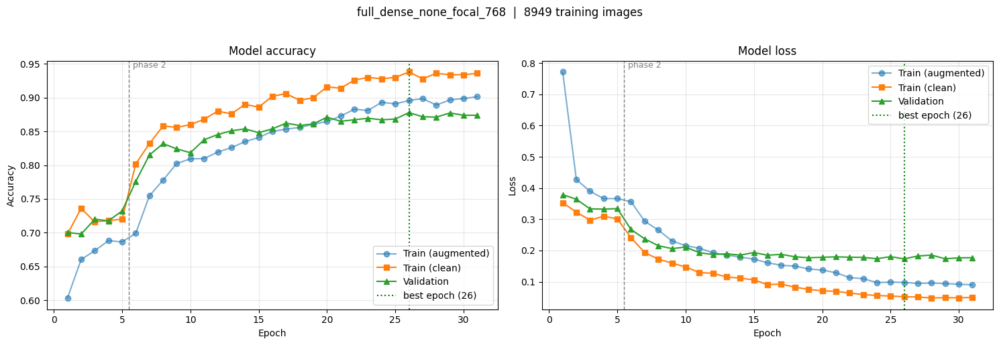

In [ ]:
# 5.4 Accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(hist['epoch'], hist[metric], 'o-', label='Train (augmented)', alpha=0.6)
    ax.plot(hist['epoch'], hist[f'clean_{metric}'], 's-', label='Train (clean)')
    ax.plot(hist['epoch'], hist[f'val_{metric}'], '^-', label='Validation')
    ax.axvline(C.PHASE1_EPOCHS + 0.5, color='grey', ls='--', lw=1)
    ax.axvline(BEST_EPOCH, color='green', ls=':', lw=1.5, label=f'best epoch ({BEST_EPOCH})')
    ax.text(C.PHASE1_EPOCHS + 0.6, ax.get_ylim()[1], ' phase 2', va='top', fontsize=9, color='grey')
    ax.set_title(f'Model {metric}'); ax.set_xlabel('Epoch'); ax.set_ylabel(metric.title())
    ax.grid(alpha=0.3); ax.legend(loc='lower right' if metric == 'accuracy' else 'upper right')
plt.suptitle(f'{C.RUN_TAG}  |  {len(train_df)} training images', y=1.02)
plt.tight_layout(); plt.savefig(RUN_DIR / 'curves.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
# 5.5 Gap between training and validation
gap = hist[['epoch', 'phase', 'accuracy', 'clean_accuracy', 'val_accuracy', 'val_loss']].copy()
gap['aug train - val'] = gap['accuracy'] - gap['val_accuracy']
gap['clean train - val'] = gap['clean_accuracy'] - gap['val_accuracy']
if 'learning_rate' in hist:
    gap['lr'] = hist['learning_rate']
print(gap.round(4).to_string(index=False))
best = gap[gap['epoch'] == BEST_EPOCH].iloc[0]
print(f"\nat the best epoch ({BEST_EPOCH}): clean train {best['clean_accuracy']:.3f} | "
      f"val {best['val_accuracy']:.3f} | real gap {best['clean train - val']:+.3f} | "
      f"gap caused by augmentation and dropout {best['clean_accuracy'] - best['accuracy']:+.3f}")

 epoch  phase  accuracy  clean_accuracy  val_accuracy  val_loss  aug train - val  clean train - val     lr
     1      1    0.6033           0.698        0.7003    0.3787          -0.0970            -0.0023    NaN
     2      1    0.6603           0.736        0.6980    0.3641          -0.0377             0.0380    NaN
     3      1    0.6735           0.716        0.7199    0.3334          -0.0464            -0.0039    NaN
     4      1    0.6882           0.718        0.7176    0.3325          -0.0294             0.0004    NaN
     5      1    0.6863           0.720        0.7322    0.3340          -0.0459            -0.0122    NaN
     6      2    0.6992           0.802        0.7759    0.2675          -0.0767             0.0261 0.0001
     7      2    0.7546           0.832        0.8151    0.2374          -0.0605             0.0169 0.0001
     8      2    0.7779           0.858        0.8319    0.2153          -0.0541             0.0261 0.0001
     9      2    0.8025           0.8

---
## Section 6: Model Evaluation

**Purpose:** get honest performance on data the model never trained or tuned on, check what it's actually looking at, and turn its probabilities into a usable referral decision.

**Internal test (6.1)**
- Predict once on the held-out DDR test set, never touched before now.
- Report accuracy, QWK, macro F1, per-class precision/recall, and a confusion matrix.

**External test (6.2)**
- Predict on all 455 IDRiD images, a different hospital and camera setup entirely.
- Compare accuracy, QWK, macro F1, and referral sensitivity/specificity against DDR test, side by side.

**Grad-CAM (6.3)**
- Show where the model's attention sits for correct predictions, and for its most confident wrong ones.
- Check attention stays inside the retina, not on the mask edge or background, ruling out an obvious shortcut.

**Demonstration (6.4)**
- Show predictions on a sample of test images, right or wrong, with confidence.
- Build a single-photo inference function, for the coursework's video demonstration.

**Referral threshold (6.5)**
- Find the probability cutoff, fitted on validation only, that keeps referral sensitivity at 95%.
- Apply that same fixed threshold, unchanged, to DDR test and IDRiD.

**Abstention (6.6)**
- Let the model defer low-confidence cases to a human instead of forcing a grade.
- Fit the confidence cutoff on validation, targeting 90% accuracy among the cases kept, then apply it unchanged to test and IDRiD.

**Run summary and comparison (6.7, 6.8)**
- Save every result, config and probability array for this run to disk.
- Compare this run against every other saved run, on the same metrics.

2026-09-18 21:00:54.122409: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 21:00:54.289728: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 21:00:55.592525: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 21:00:55.780591: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 21:00:57.305413: E external/local_xla/xla/stream_

DDR test (1788 images): accuracy 0.8686 | QWK 0.8866 | macro F1 0.7295

                  precision    recall  f1-score   support

           No_DR      0.911     0.959     0.934       897
            Mild      0.581     0.467     0.518        92
        Moderate      0.860     0.829     0.844       637
          Severe      0.442     0.576     0.500        33
Proliferative_DR      0.912     0.798     0.851       129

        accuracy                          0.869      1788
       macro avg      0.741     0.726     0.730      1788
    weighted avg      0.867     0.869     0.867      1788

                       pred_No_DR  pred_Mild  pred_Moderate  pred_Severe  pred_Proliferative_DR
true_No_DR                    860          9             28            0                      0
true_Mild                      19         43             30            0                      0
true_Moderate                  62         21            528           18                      8
true_Severe        

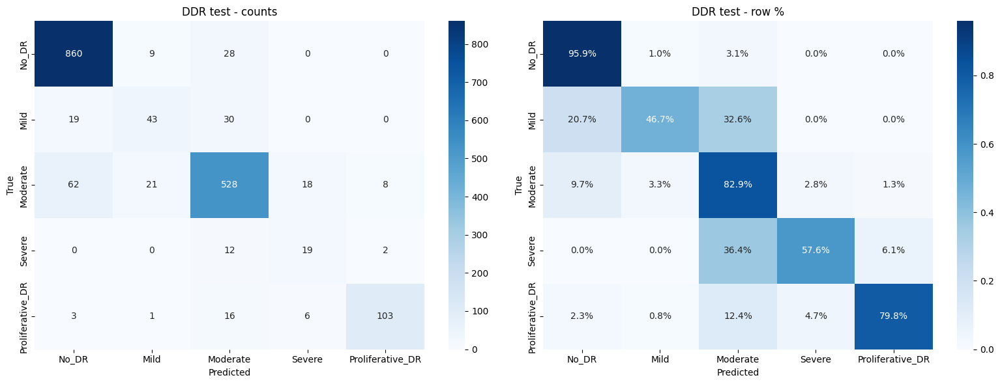

In [ ]:
# 6.1 DDR test set: metrics, classification report, confusion matrix
def metrics(y, p):
    yh = p.argmax(1)
    ref_t, ref_p = y >= 2, yh >= 2
    rec = recall_score(y, yh, labels=range(5), average=None, zero_division=0)
    out = {'accuracy': accuracy_score(y, yh), 'QWK': cohen_kappa_score(y, yh, weights='quadratic'),
           'macro F1': f1_score(y, yh, average='macro', labels=range(5), zero_division=0),
           'referable sens': (ref_t & ref_p).sum() / max(ref_t.sum(), 1),
           'referable spec': (~ref_t & ~ref_p).sum() / max((~ref_t).sum(), 1),
           'referable AUC': roc_auc_score(ref_t, p[:, 2:].sum(1)) if 0 < ref_t.sum() < len(y) else np.nan}
    out.update({f'recall {LABELS[i]}': rec[i] for i in range(5)})
    return {k: float(v) for k, v in out.items()}

def plot_cm(y, yh, title, fname):
    cm = confusion_matrix(y, yh, labels=range(5))
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=LABELS, yticklabels=LABELS)
    sns.heatmap(cm / cm.sum(1, keepdims=True).clip(min=1), annot=True, fmt='.1%', cmap='Blues', ax=axes[1],
                xticklabels=LABELS, yticklabels=LABELS)
    for ax, t in zip(axes, ['counts', 'row %']):
        ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(f'{title} - {t}')
    plt.tight_layout(); plt.savefig(RUN_DIR / fname, dpi=130, bbox_inches='tight'); plt.show()

p_val  = model.predict(val_ds, verbose=0)
p_test = model.predict(test_ds, verbose=0)
R = {'val': metrics(y_val, p_val), 'test': metrics(y_test, p_test)}

print(f"DDR test ({len(y_test)} images): accuracy {R['test']['accuracy']:.4f} | QWK {R['test']['QWK']:.4f} | "
      f"macro F1 {R['test']['macro F1']:.4f}\n")
print(classification_report(y_test, p_test.argmax(1), labels=range(5), target_names=LABELS, digits=3, zero_division=0))
cm = confusion_matrix(y_test, p_test.argmax(1), labels=range(5))
print(pd.DataFrame(cm, index=[f'true_{l}' for l in LABELS], columns=[f'pred_{l}' for l in LABELS]).to_string())

plot_cm(y_test, p_test.argmax(1), 'DDR test', 'cm_test.png')

2026-09-18 21:01:16.952532: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 21:01:17.101988: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 21:01:18.135658: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 21:01:18.300612: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 21:01:19.503002: E external/local_xla/xla/stream_

                  precision    recall  f1-score   support

           No_DR      0.947     0.610     0.742       118
            Mild      0.533     0.348     0.421        23
        Moderate      0.581     0.945     0.719       164
          Severe      0.609     0.467     0.528        90
Proliferative_DR      0.964     0.450     0.614        60

        accuracy                          0.668       455
       macro avg      0.727     0.564     0.605       455
    weighted avg      0.729     0.668     0.658       455

                       pred_No_DR  pred_Mild  pred_Moderate  pred_Severe  pred_Proliferative_DR
true_No_DR                    860          9             28            0                      0
true_Mild                      19         43             30            0                      0
true_Moderate                  62         21            528           18                      8
true_Severe                     0          0             12           19                   

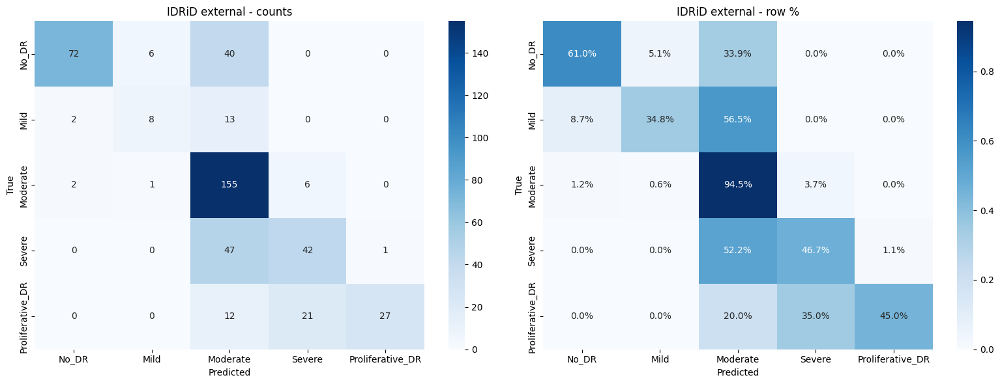

                            val    test   idrid
accuracy                 0.8779  0.8686  0.6681
QWK                      0.9036  0.8866  0.7621
macro F1                 0.7301  0.7295  0.6049
referable sens           0.9157  0.8911  0.9904
referable spec           0.9325  0.9414  0.6241
referable AUC            0.9711  0.9730  0.9657
recall No_DR             0.9572  0.9588  0.6102
recall Mild              0.3297  0.4674  0.3478
recall Moderate          0.8649  0.8289  0.9451
recall Severe            0.6061  0.5758  0.4667
recall Proliferative_DR  0.8538  0.7984  0.4500


In [ ]:
# 6.2 IDRiD external test
p_idrid = model.predict(idrid_ds, verbose=0)
R['idrid'] = metrics(y_idrid, p_idrid)
print(classification_report(y_idrid, p_idrid.argmax(1), labels=range(5), target_names=LABELS, digits=3, zero_division=0))
cm = confusion_matrix(y_test, p_test.argmax(1), labels=range(5))
print(pd.DataFrame(cm, index=[f'true_{l}' for l in LABELS], columns=[f'pred_{l}' for l in LABELS]).to_string())
plot_cm(y_idrid, p_idrid.argmax(1), 'IDRiD external', 'cm_idrid.png')

compare = pd.DataFrame(R).T
print(compare[['accuracy', 'QWK', 'macro F1', 'referable sens', 'referable spec', 'referable AUC']
              + [f'recall {l}' for l in LABELS]].round(4).T.to_string())

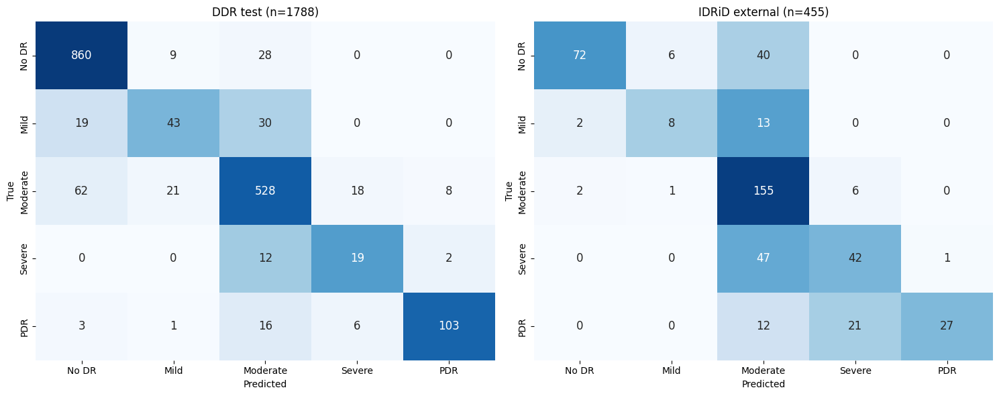

In [ ]:
# 6.2c Confusion matrices side by side (counts, shaded by row share)
short = ['No DR', 'Mild', 'Moderate', 'Severe', 'PDR']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (title, y, p) in zip(axes, [(f'DDR test (n={len(y_test)})', y_test, p_test),
                                     (f'IDRiD external (n={len(y_idrid)})', y_idrid, p_idrid)]):
    cm = confusion_matrix(y, p.argmax(1), labels=range(5))
    sns.heatmap(cm / cm.sum(1, keepdims=True).clip(min=1), annot=cm, fmt='d', cmap='Blues', vmin=0, vmax=1,
                cbar=False, ax=ax, xticklabels=short, yticklabels=short, annot_kws={'size': 12})
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
plt.tight_layout(); save_fig('fig_7_confusion_matrices'); plt.show()

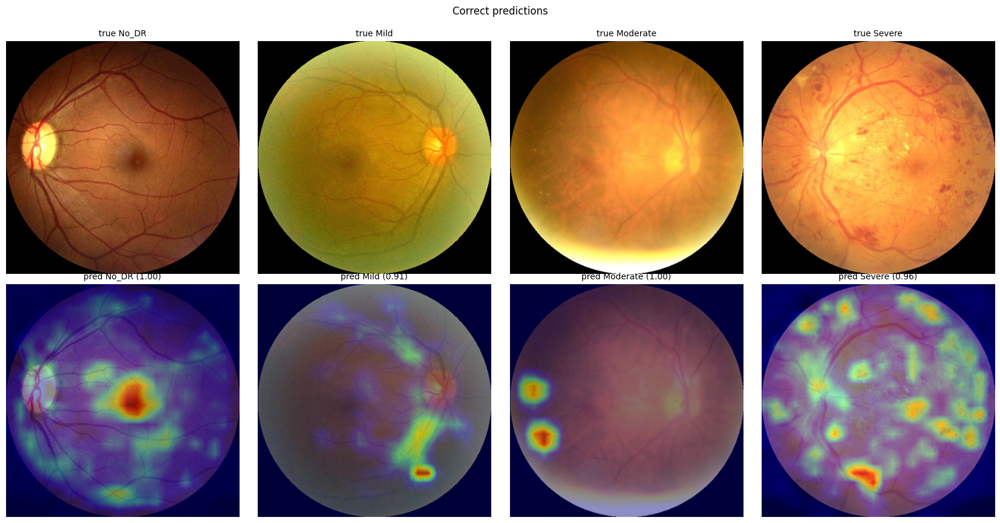

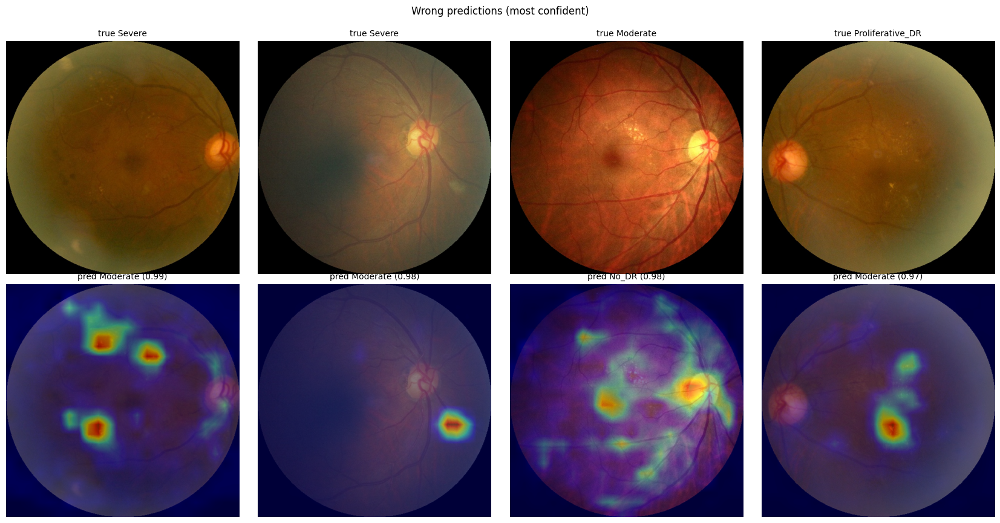

In [ ]:
# 6.3 Grad-CAM: which parts of the retina drove the prediction
feat_model = keras.Model(base.input, base.output)
head = model.layers[[l.name for l in model.layers].index('gap'):]

def gradcam(x):
    x = tf.constant(x, tf.float32)
    with tf.GradientTape() as tape:
        conv = feat_model(x, training=False)
        tape.watch(conv)
        z = conv
        for layer in head:
            z = layer(z, training=False)
        cls = tf.argmax(z, axis=1)
        score = tf.gather(z, cls, axis=1, batch_dims=1)
    g = tape.gradient(score, conv)
    cam = tf.nn.relu(tf.reduce_sum(tf.reduce_mean(g, axis=(1, 2), keepdims=True) * conv, -1))
    return (cam / (tf.reduce_max(cam, axis=(1, 2), keepdims=True) + 1e-8)).numpy(), z.numpy()

conf, pred = p_test.max(1), p_test.argmax(1)
right = [np.where((y_test == c) & (pred == c))[0] for c in range(5)]
picks_ok = [idx[np.argmax(conf[idx])] for idx in right if len(idx)][:4]
wrong = np.where(pred != y_test)[0]
picks_bad = list(wrong[np.argsort(-conf[wrong])][:4])

for title, picks in [('Correct predictions', picks_ok), ('Wrong predictions (most confident)', picks_bad)]:
    imgs = np.stack([load_image(PROC / 'ddr' / test_df['id_code'].iloc[i]) for i in picks])
    cams, probs = gradcam(imgs)
    assert np.allclose(probs, p_test[picks], atol=2e-3), 'Grad-CAM path does not match the model'
    fig, axes = plt.subplots(2, len(picks), figsize=(4.2 * len(picks), 8.6), squeeze=False)
    for k, i in enumerate(picks):
        rgb = imgs[k].astype(np.uint8)
        axes[0, k].imshow(rgb); axes[0, k].set_title(f'true {LABELS[y_test[i]]}', fontsize=10)
        axes[1, k].imshow(rgb)
        axes[1, k].imshow(cv2.resize(cams[k], (C.IMG_SIZE, C.IMG_SIZE)), cmap='jet', alpha=0.45)
        axes[1, k].set_title(f'pred {LABELS[pred[i]]} ({conf[i]:.2f})', fontsize=10)
        axes[0, k].axis('off'); axes[1, k].axis('off')
    plt.suptitle(title, y=1.0)
    plt.tight_layout(); plt.savefig(RUN_DIR / f"gradcam_{'ok' if picks is picks_ok else 'bad'}.png",
                                    dpi=120, bbox_inches='tight'); plt.show()

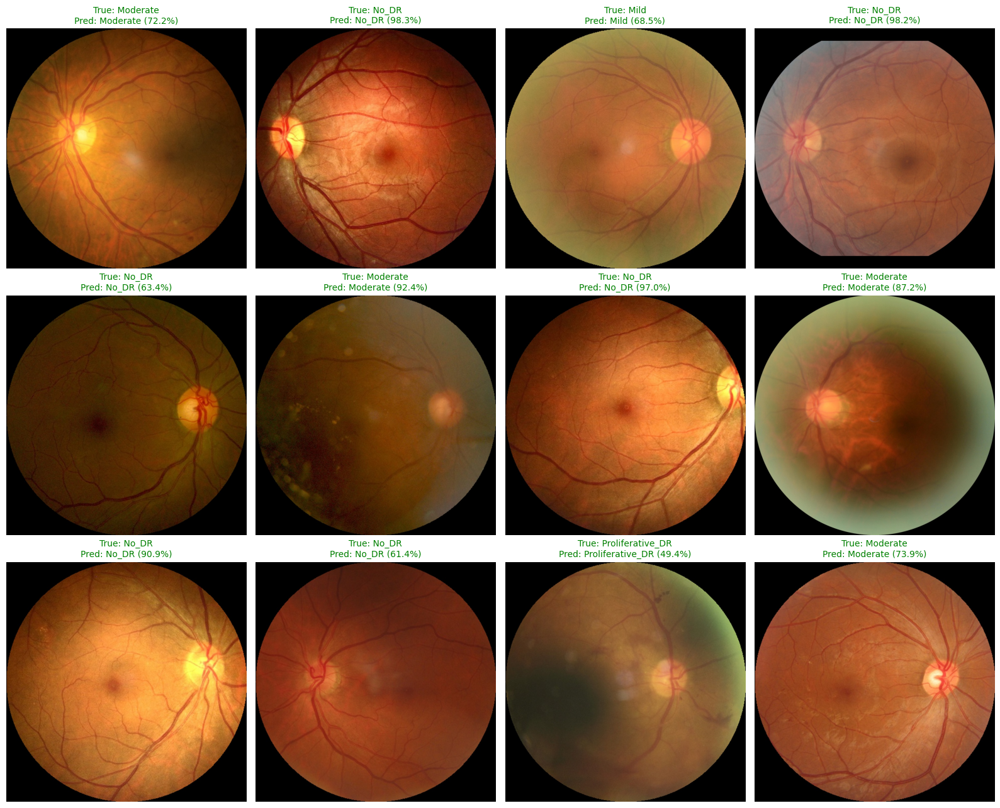

2026-09-18 21:01:52.856462: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 21:01:52.990361: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 21:01:53.762932: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 21:01:53.899682: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 21:01:54.666785: E external/local_xla/xla/stream_

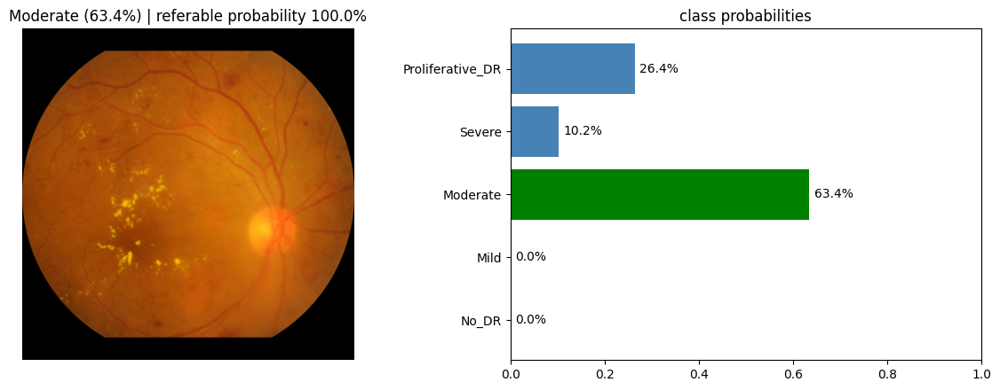

{'grade': 'Moderate', 'confidence': 0.6343411803245544, 'referable_prob': 0.9997819662094116, 'probabilities': {'No_DR': 9.999999747378752e-05, 'Mild': 9.999999747378752e-05, 'Moderate': 0.6342999935150146, 'Severe': 0.10180000215768814, 'Proliferative_DR': 0.2635999917984009}}


In [ ]:
# 6.4 Prediction grid and single-image inference
rng = np.random.default_rng(C.SEED)
sel = rng.choice(len(test_df), 12, replace=False)
fig, axes = plt.subplots(3, 4, figsize=(16, 13))
for ax, i in zip(axes.ravel(), sel):
    ok = p_test[i].argmax() == y_test[i]
    ax.imshow(load_image(PROC / 'ddr' / test_df['id_code'].iloc[i]).astype(np.uint8))
    ax.set_title(f'True: {LABELS[y_test[i]]}\nPred: {LABELS[p_test[i].argmax()]} ({p_test[i].max():.1%})',
                 color='green' if ok else 'red', fontsize=10)
    ax.axis('off')
plt.tight_layout(); plt.savefig(RUN_DIR / 'predictions.png', dpi=120, bbox_inches='tight'); plt.show()

def predict_single_image(path, raw=True):
    img = preprocess(path) if raw else cv2.imread(str(path))
    assert img is not None, f'could not read or find a retina in {path}'
    if C.NORM == 'clahe':
        img = apply_clahe(img)
    x = cv2.cvtColor(cv2.resize(img, (C.IMG_SIZE, C.IMG_SIZE)), cv2.COLOR_BGR2RGB).astype(np.float32)
    p = model.predict(x[None], verbose=0)[0]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].imshow(x.astype(np.uint8)); axes[0].axis('off')
    axes[0].set_title(f'{LABELS[p.argmax()]} ({p.max():.1%}) | referable probability {p[2:].sum():.1%}')
    axes[1].barh(LABELS, p, color=['green' if i == p.argmax() else 'steelblue' for i in range(5)])
    axes[1].set_xlim(0, 1); axes[1].set_title('class probabilities')
    for i, v in enumerate(p):
        axes[1].text(v + 0.01, i, f'{v:.1%}', va='center')
    plt.tight_layout(); plt.show()
    return {'grade': LABELS[p.argmax()], 'confidence': float(p.max()), 'referable_prob': float(p[2:].sum()),
            'probabilities': dict(zip(LABELS, p.round(4).tolist()))}

print(predict_single_image(IDRID_IMG / f"{idr['id_code'].iloc[0]}.jpg"))

referral threshold: 0.35
              sensitivity  specificity  missed  referred %
val @ 0.5          0.8934       0.9417    86.0     43.5854
val @ 0.35         0.9504       0.8650    40.0     50.3641
test @ 0.5         0.8798       0.9575    96.0     41.6667
test @ 0.35        0.9362       0.8888    51.0     47.9866
IDRiD @ 0.5        0.9841       0.6383     5.0     79.1209
IDRiD @ 0.35       0.9936       0.5603     2.0     82.1978


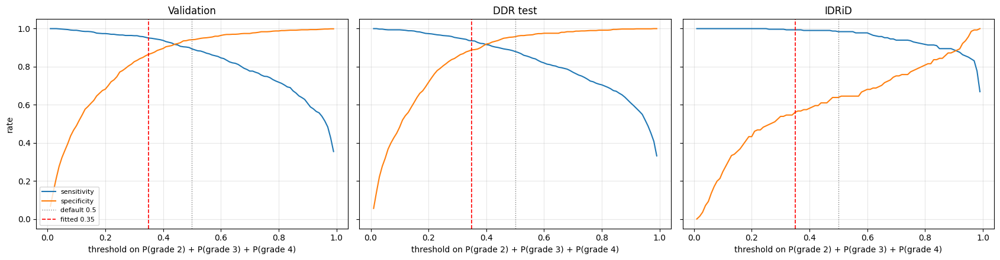

In [ ]:
# 6.5 Referral threshold (fitted on validation, applied to test and IDRiD)
# refer when P(Moderate) + P(Severe) + P(PDR) >= t; choose the highest t that still catches 95% on validation
def referral(y, p, t):
    ref_t, ref_p = y >= 2, p[:, 2:].sum(1) >= t
    return {'sensitivity': (ref_t & ref_p).sum() / ref_t.sum(), 'specificity': (~ref_t & ~ref_p).sum() / (~ref_t).sum(),
            'missed': int((ref_t & ~ref_p).sum()), 'referred %': 100 * ref_p.mean()}

grid = np.round(np.arange(0.01, 1.0, 0.01), 2)
ok = [t for t in grid if referral(y_val, p_val, t)['sensitivity'] >= 0.95]
REF_T = float(max(ok)) if ok else 0.5
rows = {f'{name} @ {t}': referral(y, p, t) for name, y, p in
        [('val', y_val, p_val), ('test', y_test, p_test), ('IDRiD', y_idrid, p_idrid)] for t in (0.5, REF_T)}
print('referral threshold:', REF_T)
print(pd.DataFrame(rows).T.round(4).to_string())
for name, y, p in [('test', y_test, p_test), ('idrid', y_idrid, p_idrid)]:
    R[name].update({f'referral sens @thr': referral(y, p, REF_T)['sensitivity'],
                    f'referral spec @thr': referral(y, p, REF_T)['specificity']})

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
for ax, (name, y, p) in zip(axes, [('Validation', y_val, p_val), ('DDR test', y_test, p_test),
                                    ('IDRiD', y_idrid, p_idrid)]):
    curve_t = pd.DataFrame([referral(y, p, t) for t in grid], index=grid)
    ax.plot(grid, curve_t['sensitivity'], label='sensitivity')
    ax.plot(grid, curve_t['specificity'], label='specificity')
    ax.axvline(0.5, color='grey', ls=':', lw=1, label='default 0.5')
    ax.axvline(REF_T, color='red', ls='--', lw=1.2, label=f'fitted {REF_T}')
    ax.set_title(name); ax.set_xlabel('threshold on P(grade 2) + P(grade 3) + P(grade 4)'); ax.grid(alpha=0.3)
axes[0].set_ylabel('rate'); axes[0].legend(fontsize=8, loc='lower left')
plt.tight_layout(); save_fig('fig_7_referral_threshold'); plt.show()


abstention threshold (validation, target accuracy >= 0.90): 0.5388
       coverage  accuracy kept  QWK kept  abstained  referable among abstained %  missed referrals (auto only)
val      0.8975         0.9114    0.9328      183.0                      51.3661                          42.0
test     0.8937         0.9074    0.9178      190.0                      49.4737                          56.0
IDRiD    0.8242         0.7040    0.7644       80.0                      67.5000                           2.0


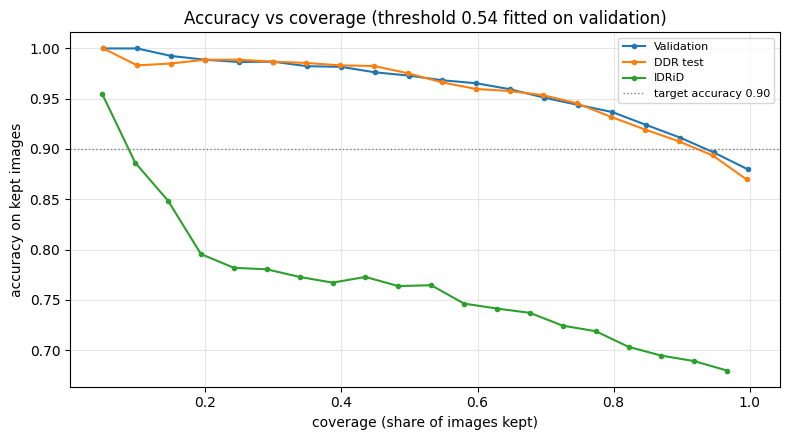

In [ ]:
# 6.6 Confidence-based abstention (fitted on validation, applied to test and IDRiD)
# abstain below a confidence threshold, rather than forcing a decision on every image;
# threshold chosen as the lowest confidence that still keeps accuracy >= 0.90 among the kept cases

def coverage_curve(y, p):
    conf = p.max(1)
    order = np.argsort(-conf)
    yh = p.argmax(1)
    correct_sorted = (yh == y)[order]
    n = len(y)
    rows = []
    for k in range(max(1, n // 20), n + 1, max(1, n // 20)):
        kept = order[:k]
        rows.append({'coverage': k / n, 'n_kept': k, 'accuracy': correct_sorted[:k].mean(),
                    'conf_cut': conf[order[k - 1]]})
    return pd.DataFrame(rows)

curve = coverage_curve(y_val, p_val)
passing = curve[curve['accuracy'] >= 0.90]
ABS_T = float(passing['conf_cut'].min()) if len(passing) else 0.0
print('abstention threshold (validation, target accuracy >= 0.90):', round(ABS_T, 4))

def abstention(y, p, t):
    conf, yh = p.max(1), p.argmax(1)
    kept = conf >= t
    ref_t = y >= 2
    auto_missed = int((ref_t & (yh < 2) & kept).sum())
    return {'coverage': float(kept.mean()), 'accuracy kept': float((yh[kept] == y[kept]).mean()) if kept.any() else np.nan,
            'QWK kept': float(cohen_kappa_score(y[kept], yh[kept], weights='quadratic')) if kept.sum() > 1 else np.nan,
            'abstained': int((~kept).sum()), 'referable among abstained %': float(100 * ref_t[~kept].mean()) if (~kept).any() else np.nan,
            'missed referrals (auto only)': auto_missed}

rows = {name: abstention(y, p, ABS_T) for name, y, p in
        [('val', y_val, p_val), ('test', y_test, p_test), ('IDRiD', y_idrid, p_idrid)]}
print(pd.DataFrame(rows).T.round(4).to_string())

for name, y, p in [('test', y_test, p_test), ('idrid', y_idrid, p_idrid)]:
    a = abstention(y, p, ABS_T)
    R[name].update({'abstention coverage': a['coverage'], 'abstention accuracy kept': a['accuracy kept'],
                    'abstention missed refs': a['missed referrals (auto only)']})

fig, ax = plt.subplots(figsize=(8, 4.5))
for name, y, p in [('Validation', y_val, p_val), ('DDR test', y_test, p_test), ('IDRiD', y_idrid, p_idrid)]:
    cc = coverage_curve(y, p)
    ax.plot(cc['coverage'], cc['accuracy'], 'o-', ms=3, label=name)
ax.axhline(0.90, color='grey', ls=':', lw=1, label='target accuracy 0.90')
ax.set_xlabel('coverage (share of images kept)'); ax.set_ylabel('accuracy on kept images')
ax.set_title(f'Accuracy vs coverage (threshold {ABS_T:.2f} fitted on validation)')
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); save_fig('fig_7_abstention'); plt.show()


In [ ]:
# 6.7 Save the run and print a summary
best_row = hist[hist['epoch'] == BEST_EPOCH].iloc[0]
results = {'run_tag': C.RUN_TAG, 'split_id': SPLIT_ID, 'train_images': len(train_df),
           'epochs_run': int(len(hist)), 'best_epoch': BEST_EPOCH, 'phase2_minutes': round(train_minutes, 1),
           'best_train_acc_clean': float(best_row['clean_accuracy']), 'best_val_acc': float(best_row['val_accuracy']),
           'gap_clean_minus_val': float(best_row['clean_accuracy'] - best_row['val_accuracy']),
           'referral_threshold': REF_T, **{f'{s}_{k}': v for s in R for k, v in R[s].items()}}
cfg = {k: (list(v) if isinstance(v, tuple) else v) for k, v in vars(Config).items() if not k.startswith('_')}
(RUN_DIR / 'results.json').write_text(json.dumps(results, indent=2, default=float))
(RUN_DIR / 'config.json').write_text(json.dumps(cfg, indent=2))
np.save(RUN_DIR / 'probs_test.npy', p_test); np.save(RUN_DIR / 'probs_idrid.npy', p_idrid)

print('=' * 70)
print('DIABETIC RETINOPATHY - RUN SUMMARY')
print('=' * 70)
print(f'run            : {C.RUN_TAG}')
print(f'data           : {len(train_df)} train | {len(val_df)} val | {len(test_df)} test | {len(idr)} IDRiD')
print(f'model          : EfficientNetV2-B0 + {C.HEAD} head | {C.IMG_SIZE}px | NORM={C.NORM} | loss={C.LOSS}')
print(f'training       : {len(hist)} epochs (best {BEST_EPOCH}) | phase 2 {train_minutes:.1f} min')
print(f"curves         : clean train {best_row['clean_accuracy']:.3f} vs val {best_row['val_accuracy']:.3f} at best epoch")
for s, name in [('test', 'DDR test'), ('idrid', 'IDRiD')]:
    print(f"{name:15s}: accuracy {R[s]['accuracy']:.4f} | QWK {R[s]['QWK']:.4f} | macro F1 {R[s]['macro F1']:.4f} | "
          f"referral sens {R[s]['referral sens @thr']:.3f} @ {REF_T}")
print('saved to       :', RUN_DIR)
print('files          :', sorted(p.name for p in RUN_DIR.iterdir()))

DIABETIC RETINOPATHY - RUN SUMMARY
run            : full_dense_none_focal_768
data           : 8949 train | 1785 val | 1788 test | 455 IDRiD
model          : EfficientNetV2-B0 + dense head | 768px | NORM=none | loss=focal
training       : 31 epochs (best 26) | phase 2 117.2 min
curves         : clean train 0.938 vs val 0.878 at best epoch
DDR test       : accuracy 0.8686 | QWK 0.8866 | macro F1 0.7295 | referral sens 0.936 @ 0.35
IDRiD          : accuracy 0.6681 | QWK 0.7621 | macro F1 0.6049 | referral sens 0.994 @ 0.35
saved to       : /kaggle/working/runs/full_dense_none_focal_768
files          : ['augmentation.png', 'best.weights.h5', 'best_qwk.weights.h5', 'cm_idrid.png', 'cm_test.png', 'config.json', 'curves.png', 'gradcam_bad.png', 'gradcam_ok.png', 'history.csv', 'history_phase1.csv', 'history_phase2.csv', 'predictions.png', 'probs_idrid.npy', 'probs_test.npy', 'results.json']


                                  train_images  epochs_run  best_epoch  best_val_acc  gap_clean_minus_val  test_accuracy  test_QWK  test_macro F1  test_recall Mild  test_recall Severe  idrid_accuracy  idrid_QWK  test_referral sens @thr        split_id
run_tag                                                                                                                                                                                                                                                    
full_dense_none_focal_768                 8949          31          26        0.8779               0.0601         0.8686    0.8866         0.7295            0.4674              0.5758          0.6681     0.7621                   0.9362  ddr_splits_7x6
full_dense_none_focal_512_merged         12263          20          15        0.8387               0.0556         0.8412    0.8571         0.6279            0.1196              0.2727          0.6044     0.7871                   0.9537  ddr_spl

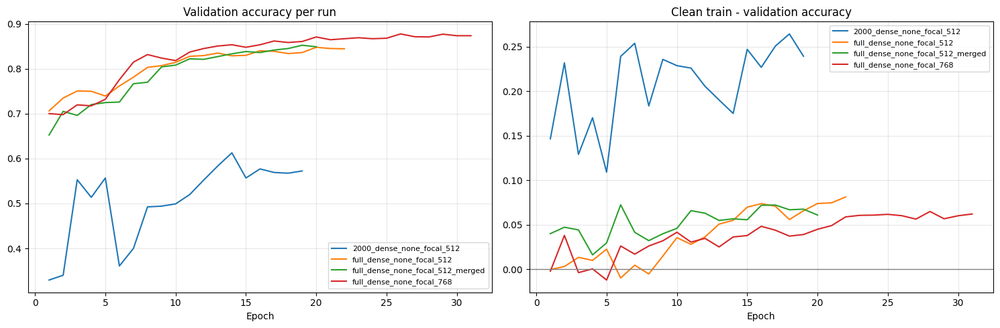

In [ ]:
# 6.8 Compare all runs (reads every runs/*/results.json in working and attached inputs)
found = {}
for path in list(RUNS.glob('*/results.json')) + list(INPUT.rglob('runs/*/results.json')):
    r = json.loads(path.read_text())
    found.setdefault(r['run_tag'], (r, path.parent))
if not found:
    print('no finished runs yet')
else:
    df_runs = pd.DataFrame([r for r, _ in found.values()]).set_index('run_tag')
    cols = ['train_images', 'epochs_run', 'best_epoch', 'best_val_acc', 'gap_clean_minus_val',
            'test_accuracy', 'test_QWK', 'test_macro F1', 'test_recall Mild', 'test_recall Severe',
            'idrid_accuracy', 'idrid_QWK', 'test_referral sens @thr', 'split_id']
    df_runs = df_runs[[c for c in cols if c in df_runs]].sort_values('test_QWK', ascending=False)
    print(df_runs.round(4).to_string())
    if df_runs['split_id'].nunique() > 1:
        print('\nWARNING: runs use different splits - compare only rows with the same split_id')

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for tag, (_, folder) in sorted(found.items()):
        hh = pd.read_csv(folder / 'history.csv')
        axes[0].plot(hh['epoch'], hh['val_accuracy'], label=tag)
        axes[1].plot(hh['epoch'], hh['clean_accuracy'] - hh['val_accuracy'], label=tag)
    axes[0].set_title('Validation accuracy per run'); axes[1].set_title('Clean train - validation accuracy')
    axes[1].axhline(0, color='grey', lw=1)
    for ax in axes:
        ax.set_xlabel('Epoch'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(RUNS / 'comparison.png', dpi=130, bbox_inches='tight'); plt.show()